# 01 — Data Pipeline Demo

Walks through fetching (or, absent a BLS API key, generating synthetic) unemployment and minimum wage data, then building the state-year analysis panel that every other notebook and the app consume.

In [1]:
import sys
sys.path.insert(0, r"C:\Users\thoma\minimum-wage-causal-inference")


In [2]:
from src.data.loader import load_state_year_panel

panel, is_synthetic = load_state_year_panel()
print(f'is_synthetic={is_synthetic}, rows={len(panel)}, states={panel.state.nunique()}')
panel.head()

is_synthetic=True, rows=380, states=20


,state,year,unemployment_rate,minimum_wage,treated,adoption_year,log_minimum_wage
0,S01,2005,6.298333,7.25,False,NaN,1.981001
1,S01,2006,5.981667,7.25,False,NaN,1.981001
2,S01,2007,6.955833,7.25,False,NaN,1.981001
3,S01,2008,6.117500,7.25,False,NaN,1.981001
4,S01,2009,5.980833,7.25,False,NaN,1.981001


If real data is available (`data/processed/panel_state_year.parquet`, built via `python -m src.data.build_panel` after setting `BLS_API_KEY` and adding a minimum wage CSV — see README), it's used automatically. Otherwise this falls back to the synthetic panel with a known ground-truth effect, so the pipeline is always runnable.

In [3]:
panel.describe()

,year,unemployment_rate,minimum_wage,adoption_year,log_minimum_wage
count,380.000000,380.000000,380.000000,247.000000,380.000000
mean,2014.000000,5.982246,8.063158,2016.846154,2.069130
std,5.484447,1.099890,1.744845,2.252509,0.179605
min,2005.000000,3.068333,7.250000,2011.000000,1.981001
25%,2009.000000,5.189167,7.250000,2016.000000,1.981001
50%,2014.000000,6.132083,7.250000,2017.000000,1.981001
75%,2019.000000,6.818542,7.250000,2019.000000,1.981001
max,2023.000000,8.588333,17.000000,2019.000000,2.833213


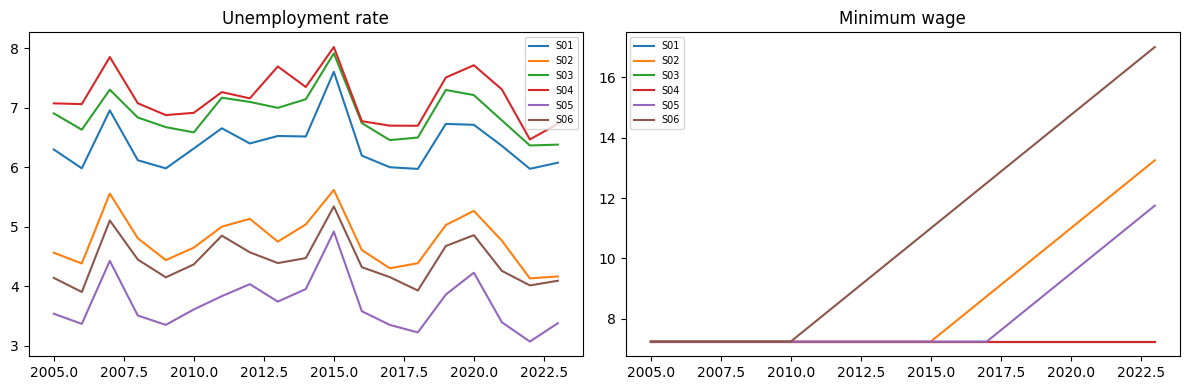

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for state in panel.state.unique()[:6]:
    sub = panel[panel.state == state]
    axes[0].plot(sub.year, sub.unemployment_rate, label=state)
    axes[1].plot(sub.year, sub.minimum_wage, label=state)
axes[0].set_title('Unemployment rate'); axes[0].legend(fontsize=7)
axes[1].set_title('Minimum wage'); axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## Sanity checks

These mirror `tests/test_build_panel.py` — no duplicate state-year rows, no missing treatment values.

In [5]:
assert not panel.duplicated(subset=['state', 'year']).any()
assert not panel['minimum_wage'].isna().any()
print('Panel passes sanity checks.')

Panel passes sanity checks.
